In [13]:
import numpy as np
# import sympy as sp
from plotly import express as px
from matplotlib import pyplot as plt
import pandas as pd
import scipy as scp


#IGUAL PARA TODOS LOS EXPERIMENTOS AL MENOS DEL MIERCOLES PASADO QSY NO CREO QUE NADIE VAYA A LEER ESTO HOLA CUCHU

f_0=16.4e3


data=pd.read_excel('dia5.ods')

In [14]:
#########FUNCIONES

def funkfit (x,a,b,c,d):
    """ a*np.sin(2 pi* b * x + c )+d """
    return a*np.sin(2*np.pi*b*x+c)+d

def B_short(x,n,a,log=False):
    if log:
        return np.exp(a)*x**n
    else:    
        return a*x**n

def lock_in(datos,f):
    x,y =datos['Second'],datos['Volt.1']
    
    # print(x,'\n',y)
    dx=x.iloc[-1]-x.iloc[0]
    
    y_cos= np.cos(2*np.pi*f*x)* y
    y_sin= np.sin(2*np.pi*f*x)* y

    U_cos=1/dx*np.trapz(y_cos,x=x)
    U_sin=1/dx*np.trapz(y_sin,x=x)

    
    # plt.figure()
    # plt.plot(y_cos)
    r=((2*U_cos)**2+(2*U_sin)**2)**.5
    phi=np.arctan2(U_sin,U_cos)

    return r,phi

In [15]:
data.columns

Index(['dist entre bobinas (bancos)', 'muV 0.01 de prefcision',
       'Fase (grados)', 'ruido muV', 'ruidofase', 'freq', 'Unnamed: 6'],
      dtype='object')

In [16]:
V=data['muV 0.01 de prefcision']*1e-6 # mv a V
d=data['dist entre bobinas (bancos)'] #tremendo nombre
d+= (5+10)*1e-2


Text(0, 0.5, 'Voltaje [V]')

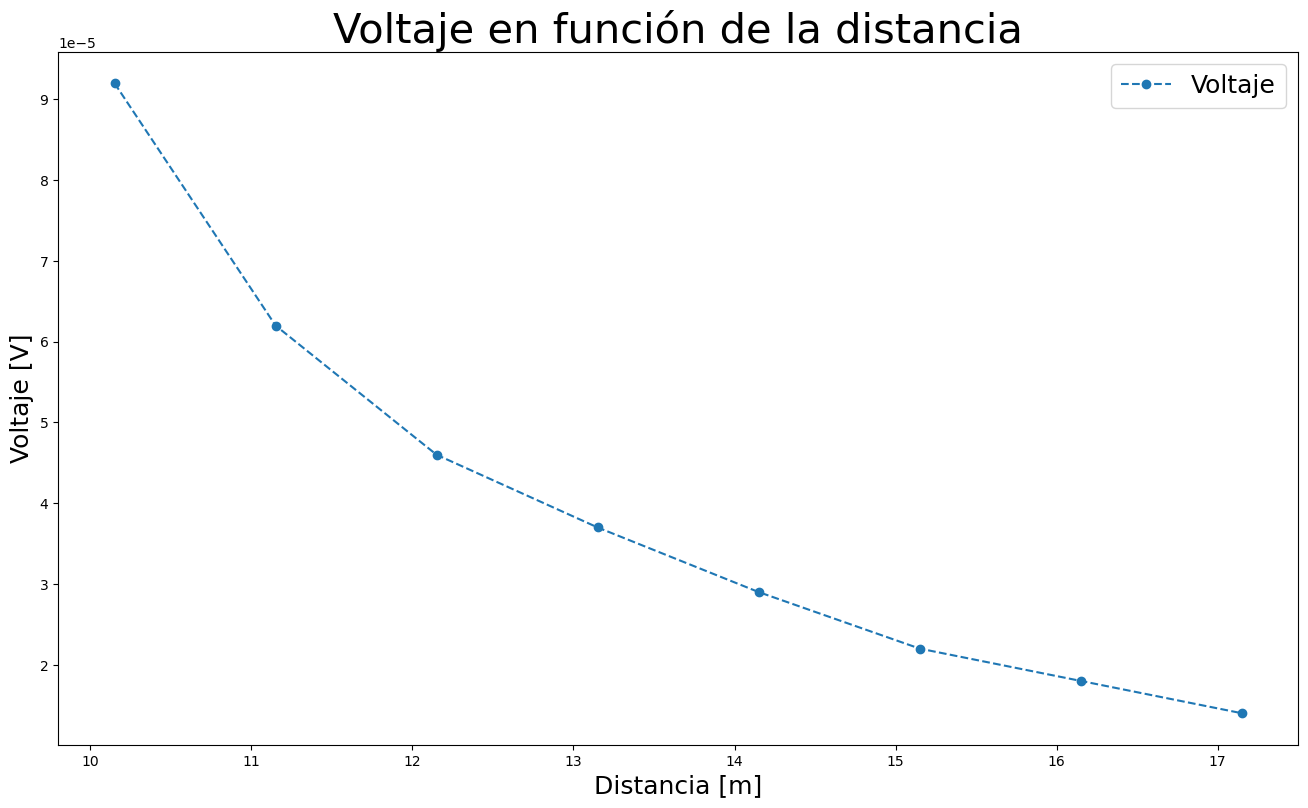

In [17]:
plt.figure(figsize=(16,9))
plt.plot(d,V,'o--')

plt.title('Voltaje en función de la distancia',fontsize=30)
plt.legend(['Voltaje'],fontsize=18)

plt.xlabel('Distancia [m]',fontsize=18)
plt.ylabel('Voltaje [V]',fontsize=18)

In [18]:
cutinf=0
cuthigh=len(V)
#n=8
# dtest=list(d[:n])+list(d[n+1:])
# vtest=list(V[:n])+list(V[n+1:])
P=np.polyfit(np.log(d[cutinf:cuthigh]),np.log(V[cutinf:cuthigh]),1)
# P=np.polyfit(np.log(dtest),np.log(vtest),1)

#P=np.polyfit(np.log(distd2[1:-1]),np.log(V2[1:-1]),1)
P


array([-3.48512641, -1.24713493])

Text(0, 0.5, 'Voltaje [V]')

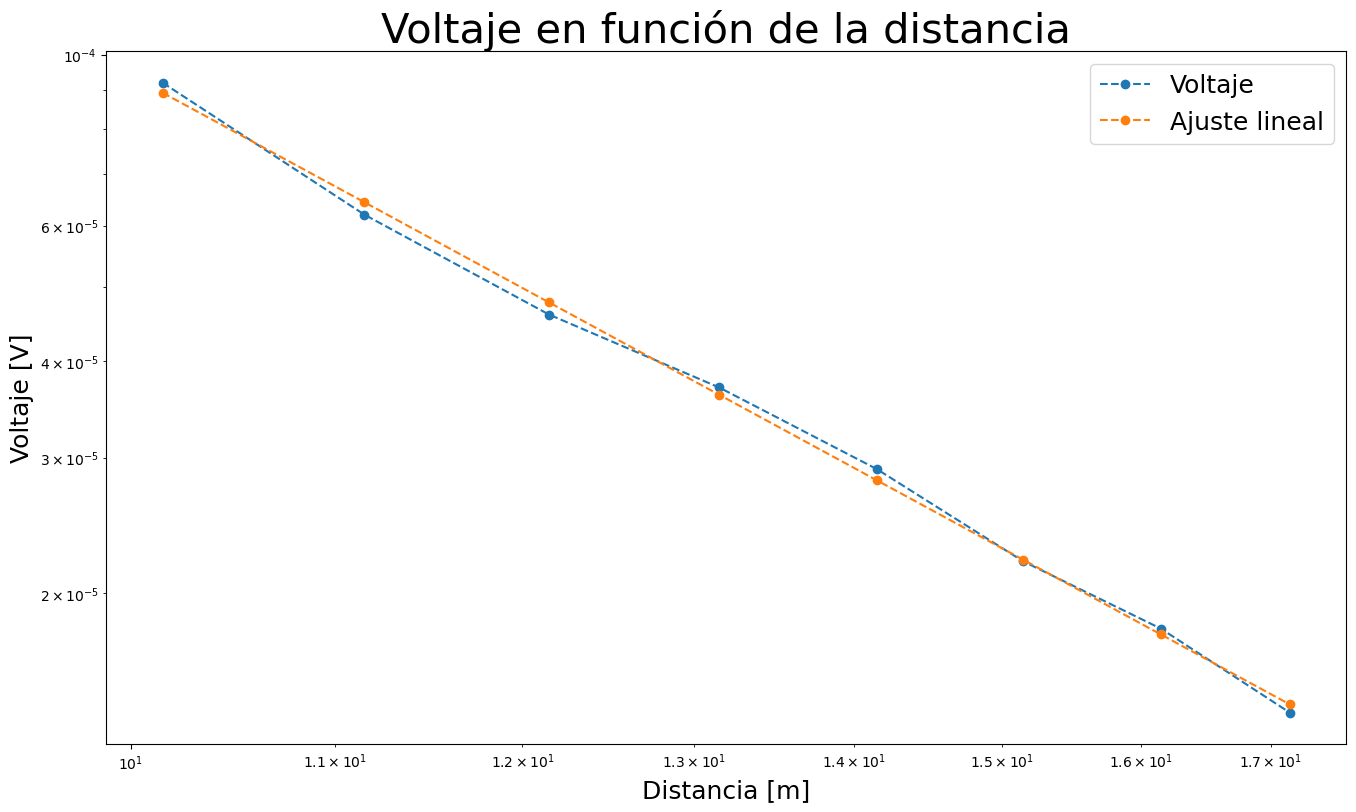

In [19]:
# n=
plt.figure(figsize=(16,9))
plt.loglog(d,V,'o--')
# plt.loglog(d[n+1:],V[n+1:],'o--','blue')
plt.loglog(d,B_short(d,*P,log=True),'o--')
plt.title('Voltaje en función de la distancia',fontsize=30)
plt.legend(['Voltaje','Ajuste lineal'],fontsize=18)

plt.xlabel('Distancia [m]',fontsize=18)
plt.ylabel('Voltaje [V]',fontsize=18)

In [21]:
pd.DataFrame({'d':d,'V':V}).to_csv('V_5_ascensor.csv',index=False)